count    102003.000000
mean          1.006521
std           0.004458
min           1.000007
25%           1.003173
50%           1.005382
75%           1.009294
max           1.018994
Name: density_score, dtype: float64


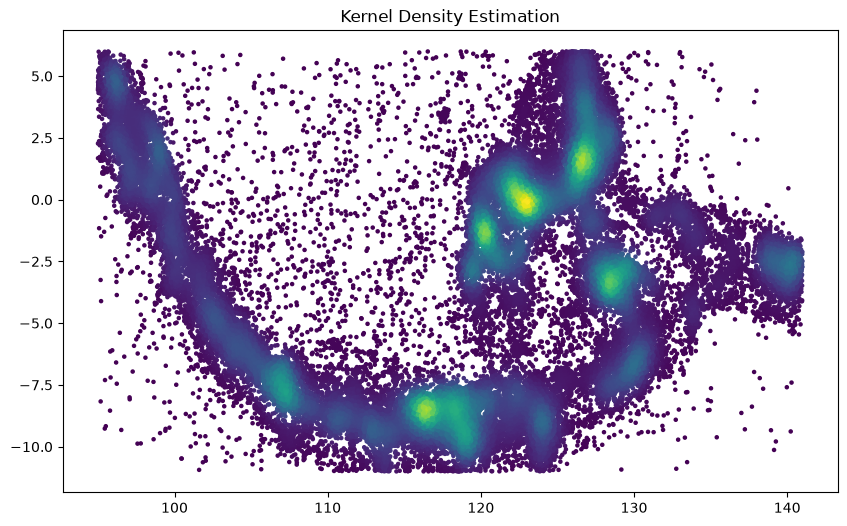

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

df = pd.read_csv("../outputs/clustered.csv")

coords = df[["latitude", "longitude"]].values
kde = KernelDensity(bandwidth=0.5, kernel="gaussian")

kde.fit(coords)

density = np.exp(kde.score_samples(coords))
df["density_score"] = np.exp(density)

df.to_csv("../outputs/kde_scored.csv", index=False)

print(df["density_score"].describe())
plt.figure(figsize=(10, 6))
plt.scatter(df["longitude"], df["latitude"], c=df["density_score"],s=5)

plt.title("Kernel Density Estimation")
plt.show()
